# IMDb Movies & TV Shows - Exploratory Data Analysis (EDA)

## Project Overview

This project performs Exploratory Data Analysis (EDA) on an IMDb dataset containing movies and TV shows. The goal is to clean the data, explore trends, analyze ratings and popularity, detect outliers, and generate meaningful insights through data visualization.

**Tools Used**
- Python
- Pandas
- Matplotlib
- Seaborn

In [10]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Dataset
imdb_data = pd.read_csv("title.combined.csv")

## Dataset Overview

In [13]:
imdb_data.info()

imdb_data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          9999 non-null   str    
 1   titleType      9999 non-null   str    
 2   genres         9998 non-null   str    
 3   numVotes       9999 non-null   int64  
 4   year           9999 non-null   int64  
 5   averageRating  9999 non-null   float64
dtypes: float64(1), int64(2), str(3)
memory usage: 468.8 KB


,numVotes,year,averageRating
count,9.999000e+03,9999.00000,9999.000000
mean,1.215959e+05,2005.50495,6.849405
std,2.002060e+05,16.87822,1.046733
min,2.017100e+04,1902.00000,1.000000
25%,3.065550e+04,1999.00000,6.200000
50%,5.417300e+04,2010.00000,6.900000
75%,1.228770e+05,2018.00000,7.600000
max,3.185932e+06,2026.00000,9.800000


## Data Cleaning

### Handling Missing Values


In [14]:
imdb_data.isnull().sum()


title            0
titleType        0
genres           1
numVotes         0
year             0
averageRating    0
dtype: int64

In [17]:
imdb_data = imdb_data.fillna({"genres":"Comedy"})

In [18]:
imdb_data.isnull().sum()

title            0
titleType        0
genres           0
numVotes         0
year             0
averageRating    0
dtype: int64

### Handling Duplicate Values 


In [33]:
imdb_data.duplicated().sum()

np.int64(0)

### Removing Extra Spaces

In [35]:
for col in imdb_data.select_dtypes(include="str").columns:
    imdb_data[col] = imdb_data[col].apply(lambda x : x.strip() if isinstance(x, str) else x)

### Converting Year Column To DateTime 

In [37]:
imdb_data["year"] = pd.to_datetime(imdb_data["year"], format="%Y")

# Exploratory Data Analysis

### Movies Released Over Time

This visualization shows how movie and TV production has evolved over the years.

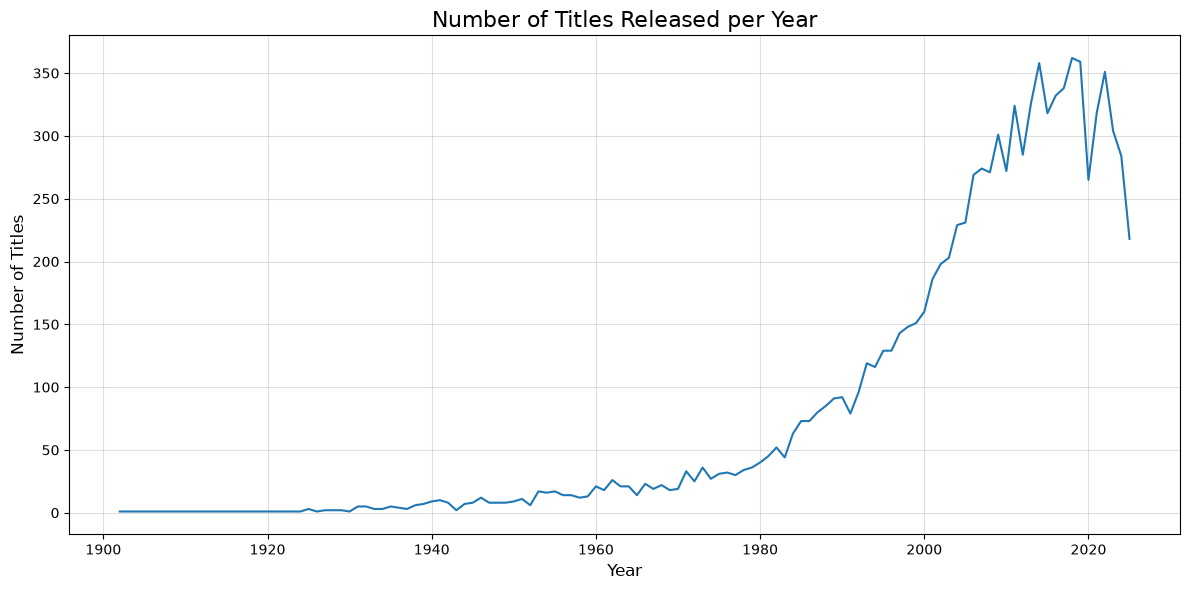

In [38]:
imdb_data["year"] = imdb_data["year"].dt.year
latest_year = imdb_data["year"].max()
filtered_imdb_data = imdb_data[imdb_data["year"]!=latest_year]
movies_year_data = filtered_imdb_data.groupby("year")["title"].count().sort_index()
plt.figure(figsize=(12,6))
plt.plot(movies_year_data.index,movies_year_data.values)
plt.title("Number of Titles Released per Year",fontsize=16)
plt.xlabel("Year",fontsize=12)
plt.ylabel("Number of Titles",fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Insight

The number of titles remained relatively low until the 1970s. Releases increased steadily after the 1980s and experienced rapid growth after 2000.

### Top 10 Years with the Highest Number of Releases

This analysis identifies the years with the highest number of movie and TV title releases in the dataset. Examining the most productive years helps reveal periods of increased content production and highlights trends in the entertainment industry.

In [45]:
top_year = imdb_data["year"].value_counts()
top_year.head(10)

year
2018    362
2019    359
2014    358
2022    351
2017    338
2016    332
2013    326
2011    324
2015    318
2021    318
Name: count, dtype: int64

### Insight

The analysis shows that **2018** recorded the highest number of title releases in the dataset. Most of the top 10 years with the highest number of releases occurred during the **2010s**, reflecting a period of rapid growth in movie and television production. This upward trend suggests an expansion of the entertainment industry, driven by increased global demand and the rise of digital streaming platforms.

### Top 10 Rated Titles

This analysis identifies the **top 10 highest-rated titles** in the dataset based on their average IMDb ratings. Ranking titles by their ratings helps highlight the productions that received the strongest audience appreciation. To ensure meaningful results, it is recommended to consider titles with a sufficient number of user votes, as ratings based on only a few votes may not accurately represent overall audience opinion.

In [44]:
top_rated = imdb_data.sort_values(by="averageRating", ascending=False)

top_rated[["title", "averageRating", "numVotes", "year"]].head(10)

,title,averageRating,numVotes,year
3684,Red Dead Redemption II,9.8,79774,2018
3322,The Last of Us,9.7,90502,2013
6290,The Witcher 3: Wild Hunt,9.6,39959,2015
8348,God of War: Ragnarök,9.5,26143,2022
8847,Steel Ball Run: JoJo's Bizarre Adventure,9.5,24126,2026
9103,Mass Effect 2,9.5,23151,2010
4,Breaking Bad,9.5,2611328,2008
5599,God of War,9.5,46534,2018
6613,Red Dead Redemption,9.4,37126,2010
1741,Planet Earth II,9.4,175007,2016


#### Insight

The analysis reveals that **Red Dead Redemption II** is the highest-rated title in the dataset with an average rating of **9.8**, followed by **The Last of Us** with a rating of **9.7**. These titles have received exceptionally positive audience feedback, making them some of the highest-rated productions in the dataset.

## Titles with the Most Votes

This analysis identifies the titles that have received the highest number of user votes on IMDb. The number of votes serves as an indicator of a title's popularity and audience engagement. Highly voted titles are typically well-known productions that have attracted a large global audience.


In [43]:
top_votes = imdb_data.sort_values(by="numVotes",ascending=False)
top_votes[["title","averageRating","numVotes","year"]].head(10)

,title,averageRating,numVotes,year
0,The Shawshank Redemption,9.3,3185932,1994
1,The Dark Knight,9.1,3165032,2008
2,Inception,8.8,2814573,2010
3,Game of Thrones,9.2,2611980,2011
4,Breaking Bad,9.5,2611328,2008
5,Fight Club,8.8,2605573,1999
6,Interstellar,8.7,2525474,2014
7,Forrest Gump,8.8,2494835,1994
8,Pulp Fiction,8.8,2433805,1994
9,The Matrix,8.7,2245953,1999


### Insight

The analysis shows that **The Shawshank Redemption** has the highest number of votes in the dataset, with approximately **3.19 million** user votes. It is followed closely by **The Dark Knight**, which has received around **3.16 million** votes. These results indicate that critically acclaimed and widely recognized films tend to attract substantial audience engagement, making them some of the most popular titles on IMDb.

## Most Common Genres

Many movies and TV shows belong to multiple genres. To analyze genre popularity accurately, the genre values were separated into individual categories before counting their frequencies. This helps identify the genres that appear most frequently in the dataset.

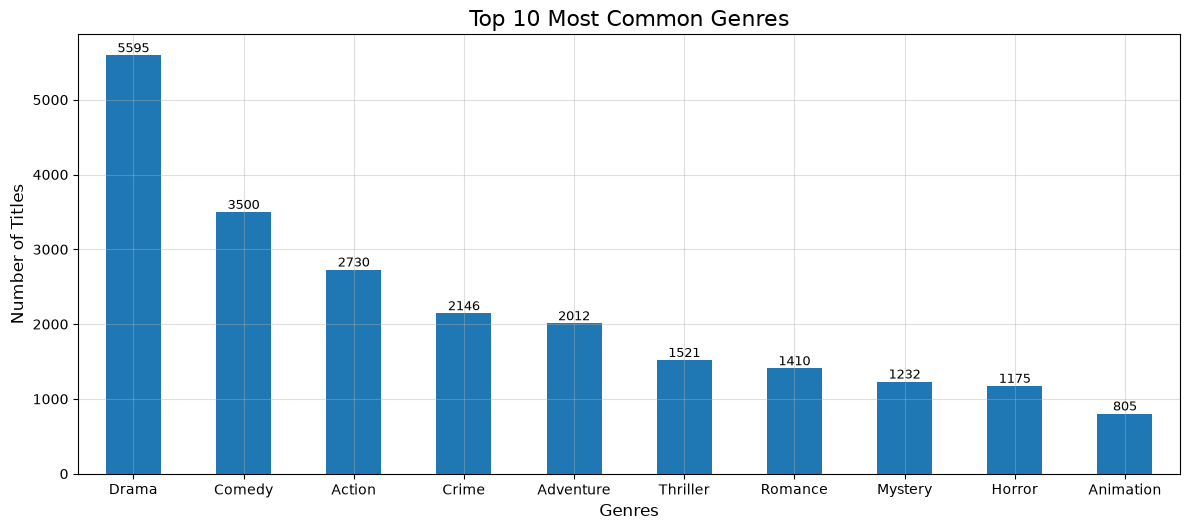

In [47]:
# Splitting the Genre column
genre_split = imdb_data["genres"].str.split(",")
# Expanding the genre columns into separate rows
genre_split= genre_split.explode()
# Counting the genres
counting_genre = genre_split.value_counts()

# Plotting the top 10 genres
top_ten_genres = counting_genre.head(10)
ax = top_ten_genres.plot(kind="bar", figsize=(12,6))

for bar in ax.patches:
     ax.annotate(
         f'{int(bar.get_height())}',
         (bar.get_x() + bar.get_width()/2, bar.get_height()),
         ha='center',
         va='bottom',
         fontsize=9
     )
plt.title("Top 10 Most Common Genres",fontsize=16)
plt.xlabel("Genres",fontsize=12)
plt.ylabel("Number of Titles",fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

### Insight

**Drama** is the most common genre in the dataset, followed by **Comedy** and **Action**. This indicates that dramatic storytelling dominates the dataset, while comedy and action also represent a large proportion of titles. Genres such as **Animation** appear less frequently among the top ten, suggesting a comparatively smaller presence.

## Movie vs TV Series

This analysis compares the number of **movies** and **TV series** in the dataset. Understanding the distribution of title types provides insight into the overall composition of the IMDb dataset.

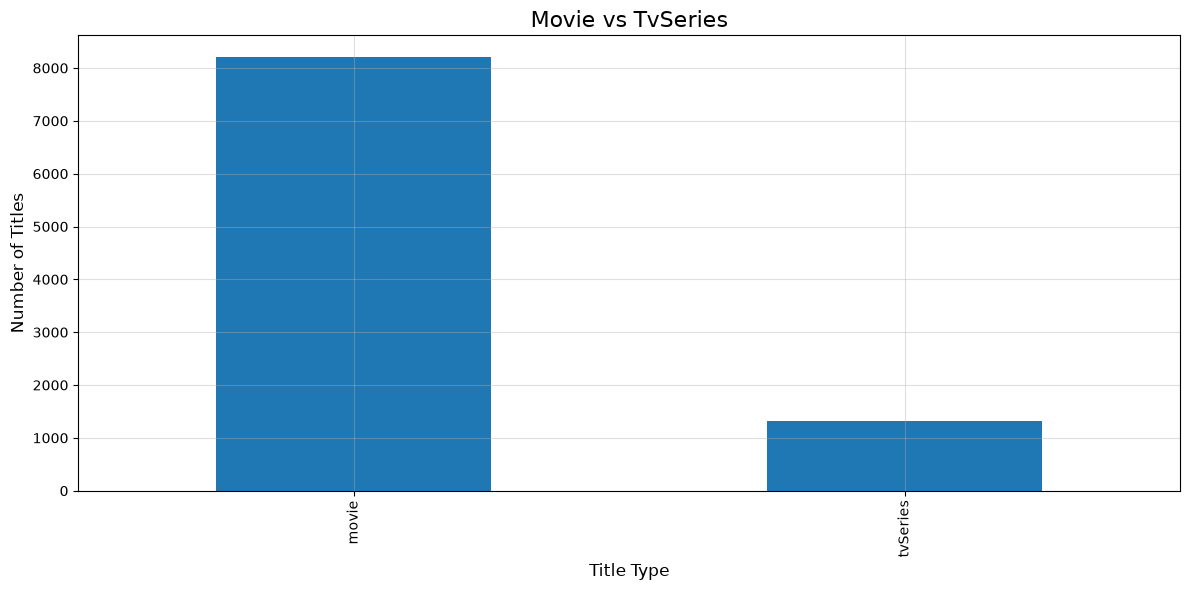

In [49]:
movies_tv_data = imdb_data[imdb_data["titleType"].isin(["movie","tvSeries"])]
# Counting Movies and TvSeries data
count_movies_tv = movies_tv_data["titleType"].value_counts()
plt.figure(figsize=(12,6))
count_movies_tv.plot(kind="bar", figsize=(12,6))
plt.title("Movie vs TvSeries",fontsize=16)
plt.xlabel("Title Type",fontsize=12)
plt.ylabel("Number of Titles",fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

### Insight

Movies constitute the majority of titles in the dataset, while TV series represent a smaller proportion. This indicates that the dataset is primarily composed of films, although television series also contribute significantly to the available content.

## Average Rating by Title Type

This analysis compares the average audience ratings of movies and TV series. Calculating the mean rating for each title type helps determine whether viewers tend to rate one type of content more favorably than the other.

titleType
tvSeries    7.767119
movie       6.664864
Name: averageRating, dtype: float64


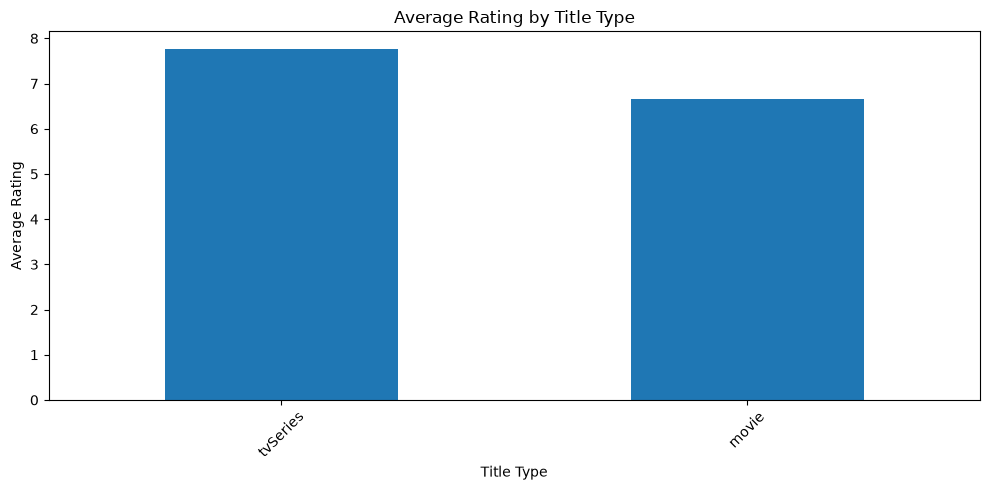

In [50]:
avg_rating = movies_tv_data.groupby("titleType")["averageRating"].mean().sort_values(ascending=False)
print(avg_rating)

plt.figure(figsize=(10,5))
avg_rating.plot(kind="bar")

plt.title("Average Rating by Title Type")
plt.xlabel("Title Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

The analysis shows that **TV series have a slightly higher average rating than movies**. Although both title types receive generally positive ratings, television series appear to achieve better audience reception on average, possibly due to their longer storytelling format and character development.

## Relationship Between Number of Votes and Average Rating

This analysis investigates whether more popular titles, measured by the number of user votes, tend to receive higher audience ratings. A scatter plot and correlation analysis were used to examine the relationship between popularity and audience satisfaction.

Correlation:0.250


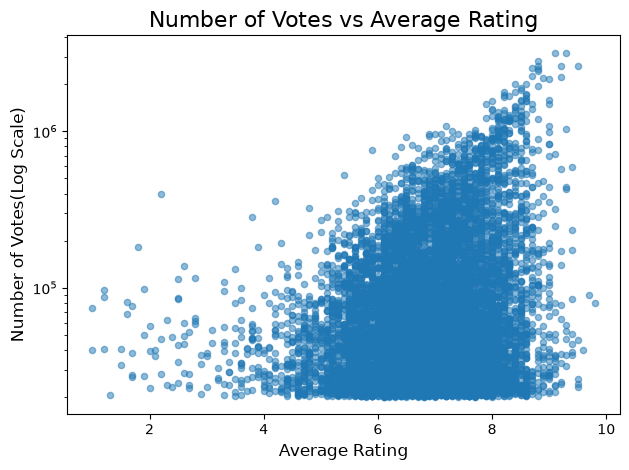

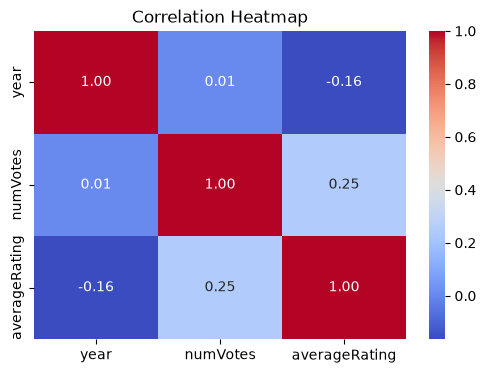

In [52]:
imdb_data.plot(kind="scatter",x="averageRating",y="numVotes",alpha=0.5)
plt.yscale("log")
plt.title("Number of Votes vs Average Rating",fontsize=16)
plt.xlabel("Average Rating",fontsize=12)
plt.ylabel("Number of Votes(Log Scale)",fontsize=12)
plt.tight_layout()

correlation = imdb_data["numVotes"].corr(imdb_data["averageRating"])
print(f"Correlation:{correlation:.3f}")
plt.figure(figsize=(6,4))
sns.heatmap(
    imdb_data[
        ["year","numVotes","averageRating"]
    ].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

### Insight

The scatter plot indicates a **weak positive relationship** between the number of votes and average rating. While titles with more votes generally tend to receive slightly higher ratings, the relationship is not strong. This suggests that popularity alone is not a reliable indicator of audience satisfaction.

## Outlier Detection - Number of Votes

The Interquartile Range (IQR) method was used to detect outliers in the **number of votes**. This helps identify titles that received an exceptionally high number of audience votes compared to the rest of the dataset.

Number of Outliers of NumVotes: 1073


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1812\1884072113.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(imdb_data["numVotes"],vert=False)


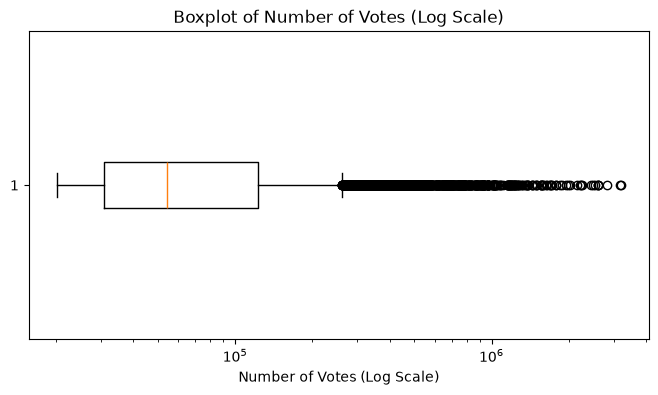

In [59]:
# Detecting Outliers in NumVotes
Q1 = imdb_data["numVotes"].quantile(0.25)
Q3 = imdb_data["numVotes"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

numVotes_outliers = imdb_data[(imdb_data["numVotes"]<lower_bound) | (imdb_data["numVotes"]>upper_bound)]
print(f"Number of Outliers of NumVotes: {len(numVotes_outliers)}")

# Visualization
plt.figure(figsize=(8,4))
plt.boxplot(imdb_data["numVotes"],vert=False)
plt.xscale("log")
plt.title("Boxplot of Number of Votes (Log Scale)")
plt.xlabel("Number of Votes (Log Scale)")
plt.show()

### Insight

The boxplot reveals a highly **right-skewed distribution** with numerous high-value outliers. These outliers represent exceptionally popular blockbuster titles that have accumulated millions of audience votes. Since these values reflect genuine observations rather than data quality issues, they were retained for further analysis.

## Outlier Detection - Average Rating

The distribution of average ratings was examined using a boxplot to identify unusually high or low audience ratings. The IQR method was applied to detect potential outliers.

Number of Outliers of Average Rating: 145


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1812\769938712.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(imdb_data["averageRating"],vert=False)


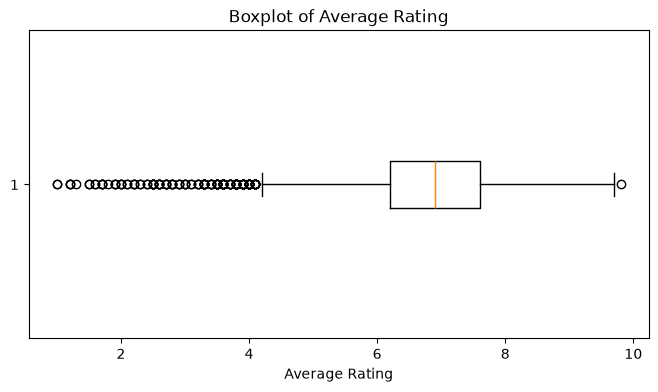

In [60]:
Q1_avg_rating = imdb_data["averageRating"].quantile(0.25)
Q3_avg_rating = imdb_data["averageRating"].quantile(0.75)
IQR_avg_rating = Q3_avg_rating - Q1_avg_rating

lower_bound = Q1_avg_rating - 1.5*IQR_avg_rating
upper_bound = Q3_avg_rating + 1.5*IQR_avg_rating
average_rating_outliers = imdb_data[(imdb_data["averageRating"]<lower_bound) | (imdb_data["averageRating"]>upper_bound)]
print(f"Number of Outliers of Average Rating: {len(average_rating_outliers)}")

plt.figure(figsize=(8,4))
plt.boxplot(imdb_data["averageRating"],vert=False)
plt.title("Boxplot of Average Rating")
plt.xlabel("Average Rating")
plt.show()

### Insight

Most titles have ratings between approximately **6 and 8**, with a median rating close to **7**. Several lower-rated titles are identified as outliers according to the IQR method, while very few high-rating outliers exist because ratings are naturally bounded by the IMDb rating scale. These observations were retained because they represent valid audience ratings rather than data quality issues.

# Key Findings

- Missing values in the genres column were replaced with "Comedy".
- No duplicate records were found.
- The number of released titles increased significantly after 2000.
- Drama is the most common genre.
- Movies are more common than TV series.
- TV series have a slightly higher average rating than movies.
- A weak positive correlation exists between number of votes and average rating.
- Outliers in the number of votes represent blockbuster titles and were retained because they are genuine observations.

# Conclusion

This project demonstrates a complete Exploratory Data Analysis workflow on an IMDb dataset. Data cleaning, visualization, statistical analysis, and outlier detection were performed to better understand movie and TV show trends.

The analysis showed that dramatic content dominates the dataset, production has increased rapidly since the early 2000s, and popularity has only a weak positive relationship with audience ratings.

The project highlights essential data analysis skills including data preprocessing, visualization, feature exploration, and insight generation using Python and Pandas.